# Alzheimer's Disease Prediction with Random Forest

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
print("Libraries loaded ✓")


Libraries loaded ✓


## 1. Load & Prepare Data

In [ ]:

df = pd.read_csv('../datasets/alzheimers_disease_data.csv')

drop_cols = ['PatientID', 'DoctorInCharge']
df = df.drop(columns=drop_cols)

X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']

print(f"Dataset shape : {df.shape}")
print(f"Features      : {X.shape[1]}")
print(f"Target balance:\n{y.value_counts().rename({0: "No Alzheimer's", 1: "Alzheimer's"}).to_string()}")


Dataset shape : (2149, 33)
Features      : 32
Target balance:
Diagnosis
No Alzheimer's    1389
Alzheimer's        760


## 2. Train / Test Split

In [3]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {X_train.shape[0]} samples")
print(f"Test size  : {X_test.shape[0]} samples")


Train size : 1719 samples
Test size  : 430 samples


## 3. Train Random Forest Model

> **Note:** `oob_score=True` enables out-of-bag evaluation — each tree is validated on the samples not used during its training, giving a free internal estimate of generalisation error without needing a separate validation set.


In [4]:

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
print(f"Test Accuracy  : {acc:.4f}")
print(f"Test ROC-AUC   : {auc:.4f}")
print(f"OOB Score      : {model.oob_score_:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No Alzheimer's", "Alzheimer's"]))


Test Accuracy  : 0.9442
Test ROC-AUC   : 0.9415
OOB Score      : 0.9459

                precision    recall  f1-score   support

No Alzheimer's       0.94      0.97      0.96       278
   Alzheimer's       0.94      0.89      0.92       152

      accuracy                           0.94       430
     macro avg       0.94      0.93      0.94       430
  weighted avg       0.94      0.94      0.94       430



## 4. Evaluation Graphs

Building OOB error curve...


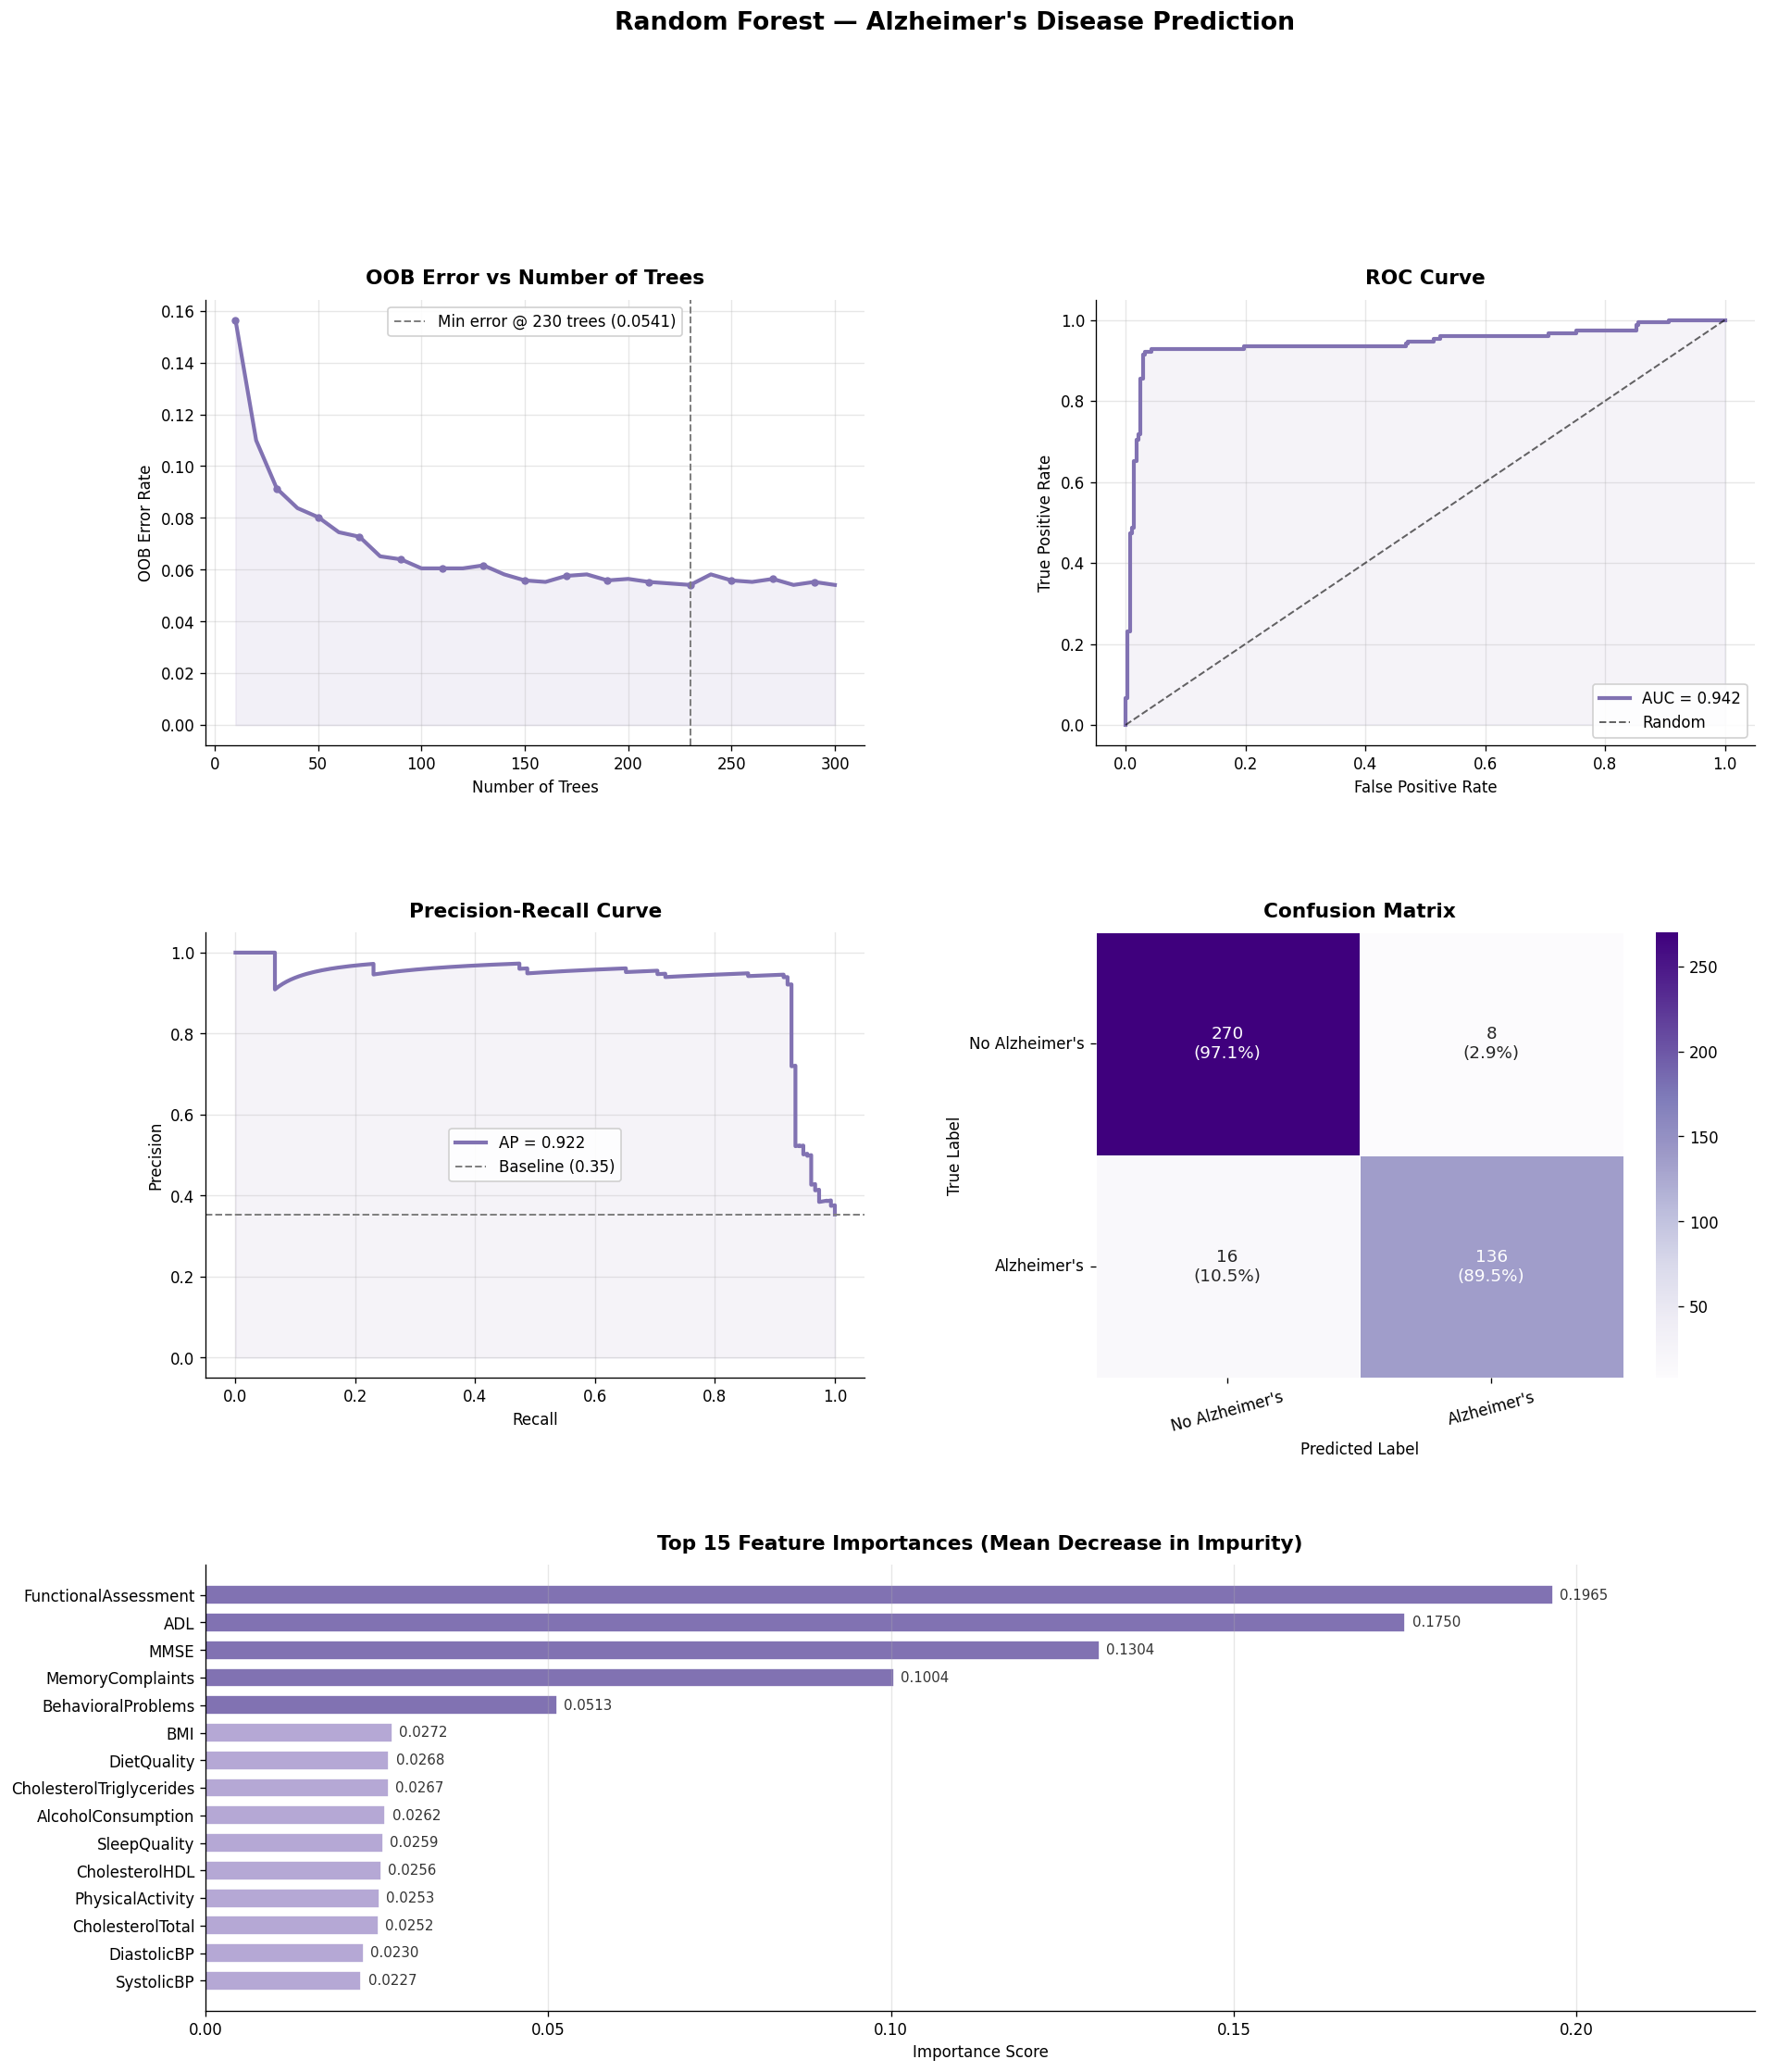

Evaluation graphs saved ✓


In [5]:

# OOB error curve — build trees incrementally using warm_start
print("Building OOB error curve...")
oob_errors = []
tree_counts = range(10, 310, 10)

for n in tree_counts:
    rf = RandomForestClassifier(
        n_estimators=n,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    oob_errors.append(1 - rf.oob_score_)

fpr, tpr, _          = roc_curve(y_test, y_proba)
roc_auc              = roc_auc_score(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)
avg_precision        = average_precision_score(y_test, y_proba)
cm                   = confusion_matrix(y_test, y_pred)

feat_imp = pd.Series(model.feature_importances_, index=X.columns) \
             .sort_values(ascending=False).head(15)

fig = plt.figure(figsize=(18, 20))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.35)

# ── 1. OOB Error Curve ─────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(list(tree_counts), oob_errors, color='#8172B2', lw=2.5, marker='o',
         markersize=4, markevery=2)
ax1.fill_between(list(tree_counts), oob_errors, alpha=0.1, color='#8172B2')
min_err  = min(oob_errors)
best_n   = list(tree_counts)[oob_errors.index(min_err)]
ax1.axvline(best_n, color='gray', lw=1.2, linestyle='--',
            label=f'Min error @ {best_n} trees ({min_err:.4f})')
ax1.set_title('OOB Error vs Number of Trees', fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel('Number of Trees')
ax1.set_ylabel('OOB Error Rate')
ax1.legend(framealpha=0.9)
ax1.grid(alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)

# ── 2. ROC Curve ───────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(fpr, tpr, color='#8172B2', lw=2.5, label=f'AUC = {roc_auc:.3f}')
ax2.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.6, label='Random')
ax2.fill_between(fpr, tpr, alpha=0.08, color='#8172B2')
ax2.set_title('ROC Curve', fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend(loc='lower right', framealpha=0.9)
ax2.grid(alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)

# ── 3. Precision-Recall Curve ──────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(recall, precision, color='#8172B2', lw=2.5, label=f'AP = {avg_precision:.3f}')
ax3.fill_between(recall, precision, alpha=0.08, color='#8172B2')
baseline = y_test.mean()
ax3.axhline(baseline, color='gray', lw=1.2, linestyle='--',
            label=f'Baseline ({baseline:.2f})')
ax3.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold', pad=10)
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.legend(framealpha=0.9)
ax3.grid(alpha=0.3)
ax3.spines[['top', 'right']].set_visible(False)

# ── 4. Confusion Matrix ────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
labels  = ["No Alzheimer's", "Alzheimer's"]
cm_pct  = cm.astype(float) / cm.sum(axis=1, keepdims=True)
annots  = np.array([[f"{cm[i,j]}\n({cm_pct[i,j]:.1%})" for j in range(2)] for i in range(2)])
sns.heatmap(cm, annot=annots, fmt='', cmap='Purples', ax=ax4,
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, linecolor='white', cbar=True,
            annot_kws={'fontsize': 11})
ax4.set_title('Confusion Matrix', fontsize=13, fontweight='bold', pad=10)
ax4.set_xlabel('Predicted Label')
ax4.set_ylabel('True Label')
ax4.tick_params(axis='x', rotation=15)
ax4.tick_params(axis='y', rotation=0)

# ── 5. Feature Importances ─────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, :])
colors = ['#8172B2' if i < 5 else '#B5A8D5' for i in range(len(feat_imp))]
bars = ax5.barh(feat_imp.index[::-1], feat_imp.values[::-1],
                color=colors[::-1], edgecolor='white', height=0.7)
for bar, val in zip(bars, feat_imp.values[::-1]):
    ax5.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center', ha='left', fontsize=9, color='#333')
ax5.set_title('Top 15 Feature Importances (Mean Decrease in Impurity)', fontsize=13, fontweight='bold', pad=10)
ax5.set_xlabel('Importance Score')
ax5.grid(axis='x', alpha=0.3)
ax5.spines[['top', 'right']].set_visible(False)
ax5.set_xlim(0, feat_imp.max() * 1.15)

fig.suptitle("Random Forest — Alzheimer's Disease Prediction", fontsize=16, fontweight='bold', y=1.01)
plt.savefig('rf_evaluation_graphs.png', bbox_inches='tight', dpi=150)
plt.show()
print("Evaluation graphs saved ✓")


## 5. Cross-Validation Summary

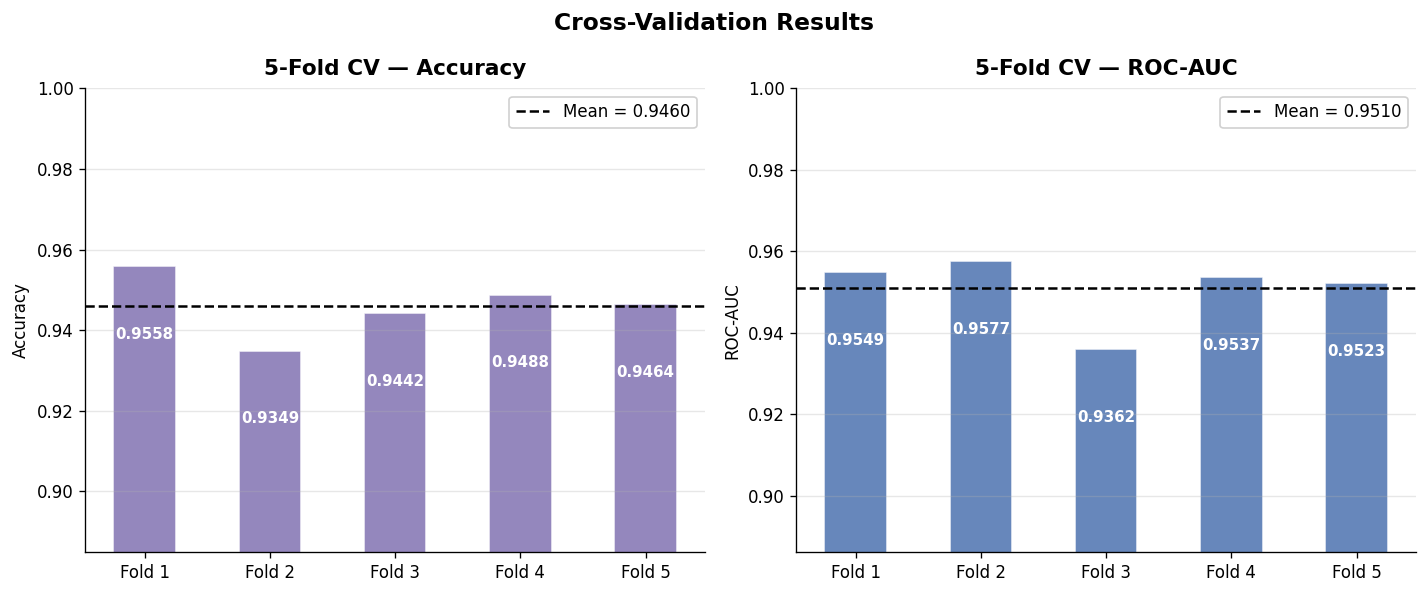

CV Accuracy : 0.9460 ± 0.0068
CV ROC-AUC  : 0.9510 ± 0.0076


In [6]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

acc_scores = cross_val_score(cv_model, X, y, cv=cv, scoring='accuracy')
auc_scores = cross_val_score(cv_model, X, y, cv=cv, scoring='roc_auc')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, scores, metric, color in zip(
        axes, [acc_scores, auc_scores],
        ['Accuracy', 'ROC-AUC'], ['#8172B2', '#4C72B0']):
    folds = [f'Fold {i+1}' for i in range(len(scores))]
    bars  = ax.bar(folds, scores, color=color, alpha=0.85, edgecolor='white', width=0.5)
    ax.axhline(scores.mean(), color='black', lw=1.5, linestyle='--',
               label=f'Mean = {scores.mean():.4f}')
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width() / 2, val - 0.015,
                f'{val:.4f}', ha='center', va='top', fontsize=9,
                color='white', fontweight='bold')
    ax.set_title(f'5-Fold CV — {metric}', fontsize=13, fontweight='bold', pad=8)
    ax.set_ylabel(metric)
    ax.set_ylim(max(0, scores.min() - 0.05), min(1, scores.max() + 0.05))
    ax.legend(framealpha=0.9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Cross-Validation Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rf_cv_results.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"CV Accuracy : {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
print(f"CV ROC-AUC  : {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")
